# Cyprus Community Bank: Loan Default Prediction

**DSC550 Group Project**

**Team members:** *(fill in)*

---

## 0. Setup and Imports

!pip install matplotlib
!pip install scikit-learn
!pip install seaborn


!pip install imbalanced-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

# Optional: SMOTE for imbalanced data
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("imbalanced-learn not installed. Install with: pip install imbalanced-learn")

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

## 1. Load Data and Exploratory Data Analysis

Start by loading the dataset, checking its shape and types, and understanding the class distribution. Key questions to answer:
- What is the default rate? What does this tell you about class imbalance?
- Which features are most correlated with default?
- Are there any patterns by loan purpose?

In [3]:
df = pd.read_csv('cyprus_bank_loans.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nDefault rate: {df['default'].mean():.2%} ({df['default'].sum()} out of {len(df)})")
df.head()

Dataset shape: (10000, 13)

Default rate: 3.09% (309 out of 10000)


,age,years_employed,annual_income,credit_score,debt_to_income_ratio,num_existing_loans,previous_defaults,loan_amount,loan_term_months,loan_purpose,avg_monthly_balance,months_as_customer,default
0,30,5,28500.0,578,0.20,1,0,10000.0,12,personal,1756.75,90,0
1,29,1,18500.0,484,0.22,0,0,13000.0,24,debt_consolidation,499.62,66,0
2,45,1,20800.0,555,0.13,0,0,5000.0,12,personal,665.56,80,0
3,57,18,52000.0,697,0.47,3,0,16500.0,36,personal,799.61,270,0
4,48,25,52200.0,443,0.38,2,0,5000.0,12,personal,1265.13,87,0


In [4]:
# Explore the data
print("=== Basic Info ===")
df.info()
print("\n=== Descriptive Statistics ===")
df.describe().round(2)
#################################

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   10000 non-null  int64  
 1   years_employed        10000 non-null  int64  
 2   annual_income         10000 non-null  float64
 3   credit_score          10000 non-null  int64  
 4   debt_to_income_ratio  10000 non-null  float64
 5   num_existing_loans    10000 non-null  int64  
 6   previous_defaults     10000 non-null  int64  
 7   loan_amount           10000 non-null  float64
 8   loan_term_months      10000 non-null  int64  
 9   loan_purpose          10000 non-null  object 
 10  avg_monthly_balance   10000 non-null  float64
 11  months_as_customer    10000 non-null  int64  
 12  default               10000 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 1015.8+ KB

=== Descriptive Statistics ===


,age,years_employed,annual_income,credit_score,debt_to_income_ratio,num_existing_loans,previous_defaults,loan_amount,loan_term_months,avg_monthly_balance,months_as_customer,default
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,40.53,8.99,32924.83,518.58,0.28,1.22,0.23,12442.95,31.92,881.12,74.83,0.03
std,9.89,6.31,15461.76,72.40,0.12,1.14,0.46,7147.01,16.33,636.93,48.15,0.17
min,21.00,0.00,15000.00,300.00,0.01,0.00,0.00,5000.00,12.00,100.00,1.00,0.00
25%,33.00,4.00,21700.00,469.00,0.19,0.00,0.00,5500.00,12.00,435.39,38.00,0.00
50%,40.00,7.00,29500.00,518.00,0.27,1.00,0.00,11000.00,24.00,726.27,66.00,0.00
75%,48.00,12.00,40200.00,567.00,0.35,2.00,0.00,17000.00,48.00,1154.80,103.00,0.00
max,69.00,42.00,159200.00,819.00,0.80,7.00,3.00,50000.00,60.00,6835.45,360.00,1.00


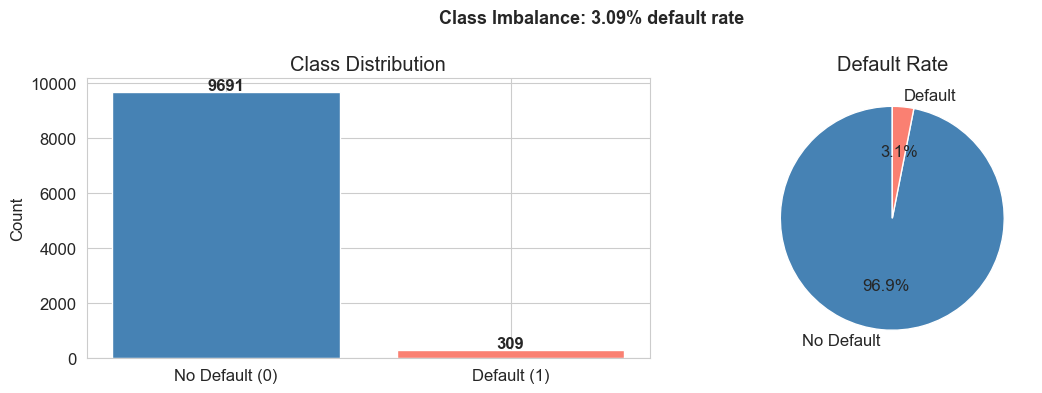

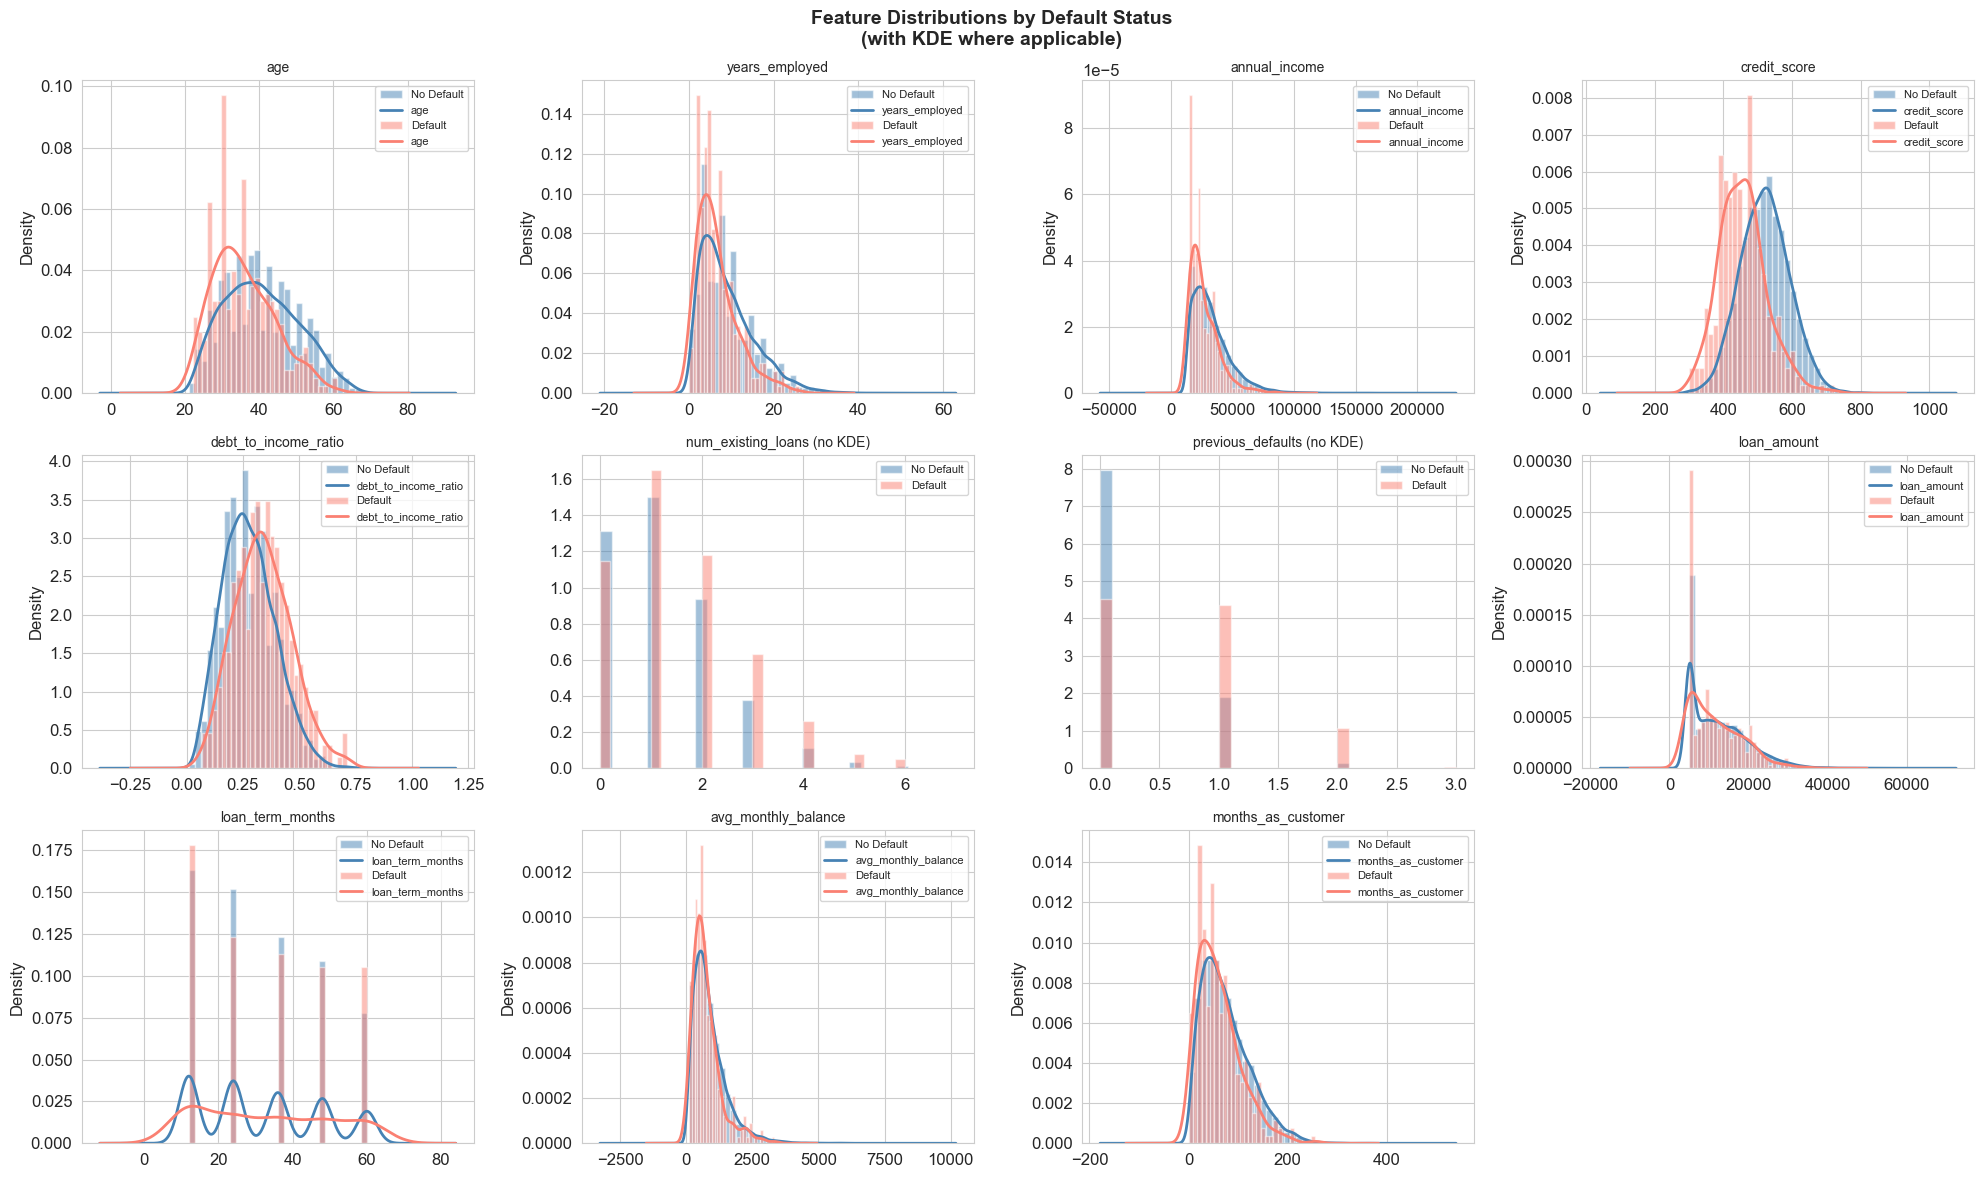

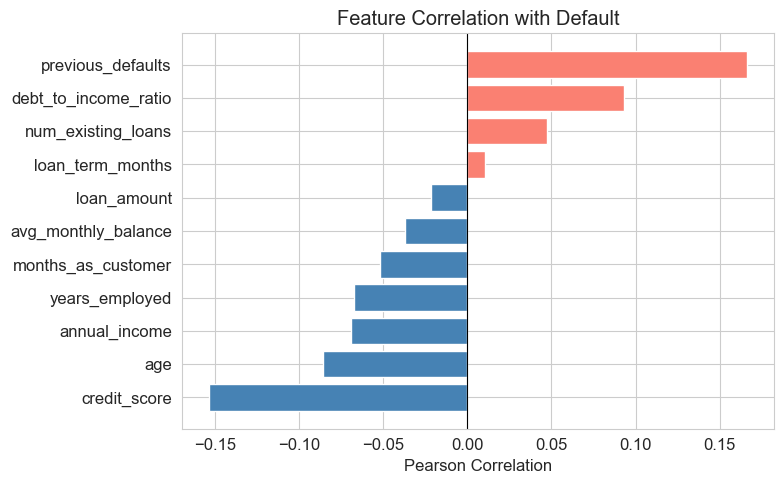

credit_score           -0.153937
age                    -0.085838
annual_income          -0.068974
years_employed         -0.067448
months_as_customer     -0.051975
avg_monthly_balance    -0.037391
loan_amount            -0.021458
loan_term_months        0.010192
num_existing_loans      0.047559
debt_to_income_ratio    0.093407
previous_defaults       0.166314

--- Default Rate by Loan Purpose ---
                    Default Rate  Count
loan_purpose                           
debt_consolidation        0.0420   2046
business                  0.0378   1456
personal                  0.0308   3082
education                 0.0278    971
home_improvement          0.0188   2445


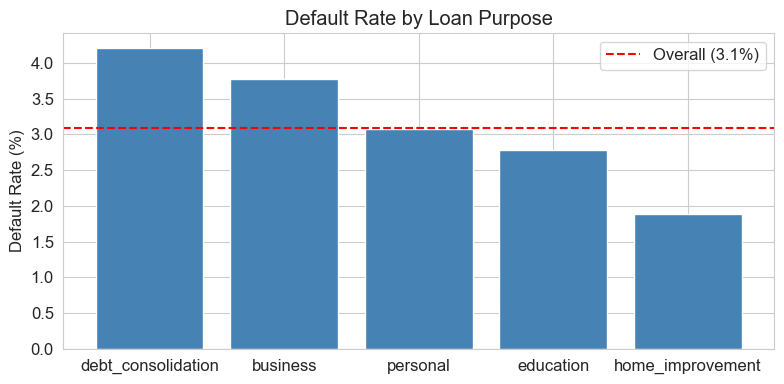

In [12]:
# --- Class distribution ---
import os; os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['default'].value_counts()
axes[0].bar(['No Default (0)', 'Default (1)'], counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Default', 'Default'], autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Default Rate')
plt.suptitle(f'Class Imbalance: {df["default"].mean():.2%} default rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Feature distributions by default status (with KDE where appropriate) ---
numeric_features = ['age', 'years_employed', 'annual_income', 'credit_score',
                    'debt_to_income_ratio', 'num_existing_loans', 'previous_defaults',
                    'loan_amount', 'loan_term_months', 'avg_monthly_balance', 'months_as_customer']

# Features that are discrete/integer-heavy: show histogram only (no KDE)
no_kde_features = {'num_existing_loans', 'previous_defaults'}

n_cols = 4
n_rows = -(-len(numeric_features) // n_cols)   # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    ax = axes[i]
    use_kde = feat not in no_kde_features
    for val, label, color in [(0, 'No Default', 'steelblue'), (1, 'Default', 'salmon')]:
        subset = df[df['default'] == val][feat]
        ax.hist(subset, bins=30, alpha=0.5, label=label, color=color, density=True)
        if use_kde:
            subset.plot.kde(ax=ax, color=color, lw=2)
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    kde_note = '' if use_kde else ' (no KDE)'
    ax.set_title(f'{feat}{kde_note}', fontsize=10)

# Hide unused subplots
for j in range(len(numeric_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Default Status\n(with KDE where applicable)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Correlation with default ---
corr = df[numeric_features + ['default']].corr()['default'].drop('default').sort_values()
plt.figure(figsize=(8, 5))
colors_corr = ['salmon' if v > 0 else 'steelblue' for v in corr.values]
plt.barh(corr.index, corr.values, color=colors_corr)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Default')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('plots/correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print(corr.to_string())

# --- Default rate by loan_purpose ---
purpose_default = df.groupby('loan_purpose')['default'].agg(['mean', 'count']).sort_values('mean', ascending=False)
purpose_default.columns = ['Default Rate', 'Count']
print("\n--- Default Rate by Loan Purpose ---")
print(purpose_default.round(4))
plt.figure(figsize=(8, 4))
plt.bar(purpose_default.index, purpose_default['Default Rate'] * 100, color='steelblue')
plt.axhline(df['default'].mean() * 100, color='red', linestyle='--', label=f'Overall ({df["default"].mean():.1%})')
plt.title('Default Rate by Loan Purpose')
plt.ylabel('Default Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/default_by_purpose.png', dpi=120, bbox_inches='tight')
plt.show()


### EDA Observations

*Summarize your key findings here:*

1. ...
2. ...
3. ...

## 2. Data Preprocessing

- Encode categorical features
- Train/test split (use stratification to maintain class proportions)
- Scale features

In [27]:
# One-hot encode loan_purpose
df_model = pd.get_dummies(df, columns=['loan_purpose'], drop_first=False)

# Features and target
feature_cols = [c for c in df_model.columns if c != 'default']
X = df_model[feature_cols]
y = df_model['default']

print(f"Features ({len(feature_cols)}): {list(feature_cols)}")
print(f"Class distribution - 0: {(y==0).sum()}, 1: {(y==1).sum()}, rate: {y.mean():.2%}")

# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train default rate: {y_train.mean():.2%}, Test default rate: {y_test.mean():.2%}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nScaling complete.")


Features (16): ['age', 'years_employed', 'annual_income', 'credit_score', 'debt_to_income_ratio', 'num_existing_loans', 'previous_defaults', 'loan_amount', 'loan_term_months', 'avg_monthly_balance', 'months_as_customer', 'loan_purpose_business', 'loan_purpose_debt_consolidation', 'loan_purpose_education', 'loan_purpose_home_improvement', 'loan_purpose_personal']
Class distribution - 0: 9691, 1: 309, rate: 3.09%

Train size: 8000, Test size: 2000
Train default rate: 3.09%, Test default rate: 3.10%

Scaling complete.


## 3. Stakeholder Cost Structures

Before building any models, define the cost structure for each stakeholder and calculate their break-even thresholds.

**Reminder:** The break-even formula is $P^* = \frac{C_{FP}}{C_{FP} + C_{FN}}$ where $C_{FP}$ is the **incremental** cost of rejecting a good loan ($\text{TN} - \text{FP}$) and $C_{FN}$ is the **incremental** cost of approving a default ($\text{TP} - \text{FN}$). These are the differences between the correct and incorrect decision for each type of applicant.

In [28]:
# Cost structures from the project brief
# TN = approve good loan (no default), FN = approve default, FP = reject good loan, TP = reject default
stakeholders = {
    'CFO': {'TN': 2400,   'FN': -15000, 'FP': 0,      'TP': 0,
            'name': 'Maria Georgiou (CFO)', 'goal': 'Maximize Profit'},
    'CRO': {'TN': 0,      'FN': -45000, 'FP': -500,   'TP': 0,
            'name': 'Andreas Konstantinou (CRO)', 'goal': 'Minimize Risk'},
    'CGO': {'TN': 8000,   'FN': -12000, 'FP': -10000, 'TP': 0,
            'name': 'Elena Papadopoulou (CGO)', 'goal': 'Maximize Growth'},
}

print("=" * 65)
print(f"{'Stakeholder':<8} {'C_FP (incr.)':<16} {'C_FN (incr.)':<16} {'P* (break-even)'}")
print("=" * 65)
for key, s in stakeholders.items():
    # Incremental cost of FP = TN - FP (swing between correct & wrong for good loan)
    c_fp = s['TN'] - s['FP']
    # Incremental cost of FN = TP - FN (swing between correct & wrong for default)
    c_fn = s['TP'] - s['FN']
    p_star = c_fp / (c_fp + c_fn)
    s['C_FP'] = c_fp
    s['C_FN'] = c_fn
    s['p_star'] = p_star
    print(f"{key:<8} €{c_fp:>12,.0f}   €{c_fn:>12,.0f}   {p_star:.4f}  ({p_star:.1%})")

print("=" * 65)
print("\nInterpretation:")
print(f"  CFO p*={stakeholders['CFO']['p_star']:.1%}: Reject only if >13.8% chance of default → profit-maximizing, fairly permissive")
print(f"  CRO p*={stakeholders['CRO']['p_star']:.1%}: Reject if >1.1% chance of default → very conservative, risk-averse")
print(f"  CGO p*={stakeholders['CGO']['p_star']:.1%}: Reject only if >40% chance of default → very permissive, growth-oriented")


Stakeholder C_FP (incr.)     C_FN (incr.)     P* (break-even)
CFO      €       2,400   €      15,000   0.1379  (13.8%)
CRO      €         500   €      45,000   0.0110  (1.1%)
CGO      €      18,000   €      12,000   0.6000  (60.0%)

Interpretation:
  CFO p*=13.8%: Reject only if >13.8% chance of default → profit-maximizing, fairly permissive
  CRO p*=1.1%: Reject if >1.1% chance of default → very conservative, risk-averse
  CGO p*=60.0%: Reject only if >40% chance of default → very permissive, growth-oriented


## 4. Helper Functions

These utility functions will be used throughout the analysis.

In [29]:
def predict_with_threshold(probabilities, threshold=0.5):
    """Convert predicted probabilities to binary predictions using a custom threshold."""
    return (probabilities >= threshold).astype(int)


def calculate_profit_per_1000(y_true, y_pred, cost_structure):
    """Calculate expected profit per 1,000 applications for a given cost structure.
    
    Parameters
    ----------
    y_true : array-like, true labels (1=default, 0=no default)
    y_pred : array-like, predicted labels (1=reject, 0=approve)
    cost_structure : dict with keys 'TN', 'FP', 'FN', 'TP'
    
    Returns
    -------
    float : expected profit scaled to 1,000 applications
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total = tn + fp + fn + tp
    
    profit = (tn * cost_structure['TN'] + 
              fp * cost_structure['FP'] + 
              fn * cost_structure['FN'] + 
              tp * cost_structure['TP'])
    
    return profit / total * 1000

## 5. Handling Imbalanced Data

The dataset has ~3% defaults, a 31:1 class imbalance. You must address this.

Train models using **two approaches** and compare them:
1. **With balancing:** `class_weight='balanced'` or SMOTE (pick one or try both)
2. **Without balancing:** train on the original imbalanced data

> **Why compare?**
> Using `class_weight='balanced'` or SMOTE improves recall at the default 0.5 threshold, but it **inflates the predicted probabilities**. This means the break-even thresholds from Section 3 won't directly match the empirically optimal thresholds you find by sweeping. Recall from the bank_credit example in class: even there the theoretical optimum (0.25) differed slightly from the empirical one (0.21). With heavy imbalance and balancing, the gap can be much larger.
>
> Training **without** balancing keeps the predicted probabilities calibrated, so the break-even formula works more directly. You then find the right cutoff by sweeping. Compare the two approaches: how do the optimal thresholds differ? How does calibration differ?

In [30]:
# Apply SMOTE to training data
if SMOTE_AVAILABLE:
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
    print(f"Before SMOTE: {pd.Series(y_train).value_counts().to_dict()}")
    print(f"After  SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")
    print(f"SMOTE expanded training set from {len(y_train):,} to {len(y_train_smote):,} samples")
else:
    # Fall back: use class_weight='balanced' in models
    X_train_smote, y_train_smote = X_train_scaled, y_train
    print("SMOTE not available; will use class_weight='balanced' in applicable models.")


Before SMOTE: {0: 7753, 1: 247}
After  SMOTE: {0: 7753, 1: 7753}
SMOTE expanded training set from 8,000 to 15,506 samples


## 6. Train and Compare Models

Train at least 5 classifiers. For each, compute: Accuracy, Precision, Recall, F1, AUC.

**Question to answer:** What accuracy does a "predict all no-default" baseline achieve? Why is accuracy misleading here?

In [31]:
# Define models (trained on SMOTE-balanced data)
models_balanced = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'LDA':                 LinearDiscriminantAnalysis(),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Naive Bayes':         GaussianNB(),
}

results = []
trained_models = {}

for name, model in models_balanced.items():
    model.fit(X_train_smote, y_train_smote)
    trained_models[name] = model
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'AUC':       roc_auc_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
print("=== Model Comparison (trained on SMOTE-balanced data) ===")
print(results_df.sort_values('AUC', ascending=False).to_string())


=== Model Comparison (trained on SMOTE-balanced data) ===
                     Accuracy  Precision  Recall      F1     AUC
Model                                                           
Logistic Regression    0.7800     0.0891  0.6613  0.1571  0.8193
LDA                    0.7685     0.0866  0.6774  0.1536  0.8186
Naive Bayes            0.6600     0.0623  0.7097  0.1146  0.7398
Gradient Boosting      0.9390     0.1809  0.2742  0.2179  0.7382
Random Forest          0.9540     0.1875  0.1452  0.1636  0.7296
KNN                    0.8355     0.0680  0.3387  0.1132  0.6157
Decision Tree          0.9160     0.0859  0.1774  0.1158  0.5585


In [32]:
# Baseline: predict "no default" for everyone
baseline_acc = accuracy_score(y_test, np.zeros(len(y_test)))
baseline_recall = recall_score(y_test, np.zeros(len(y_test)), zero_division=0)
print(f"Naive Baseline (predict all 0): Accuracy = {baseline_acc:.4f}, Recall = {baseline_recall:.4f}")
print(f"\n→ A model that always predicts 'no default' achieves {baseline_acc:.1%} accuracy")
print(f"  yet catches ZERO defaults (recall = 0). Accuracy is misleading because")
print(f"  the dataset is heavily imbalanced (~3% defaults). The majority class")
print(f"  dominates the metric. We should instead focus on AUC, Recall, and F1.")


Naive Baseline (predict all 0): Accuracy = 0.9690, Recall = 0.0000

→ A model that always predicts 'no default' achieves 96.9% accuracy
  yet catches ZERO defaults (recall = 0). Accuracy is misleading because
  the dataset is heavily imbalanced (~3% defaults). The majority class
  dominates the metric. We should instead focus on AUC, Recall, and F1.


## 7. Balanced vs. Unbalanced Comparison

Compare your best model trained **with** balancing vs. **without** balancing. How do the optimal thresholds differ? How does calibration differ? You can also compare `class_weight='balanced'` vs. SMOTE if you tried both.

Gradient Boosting WITHOUT balancing → AUC: 0.8030
Gradient Boosting WITH SMOTE        → AUC: 0.7382


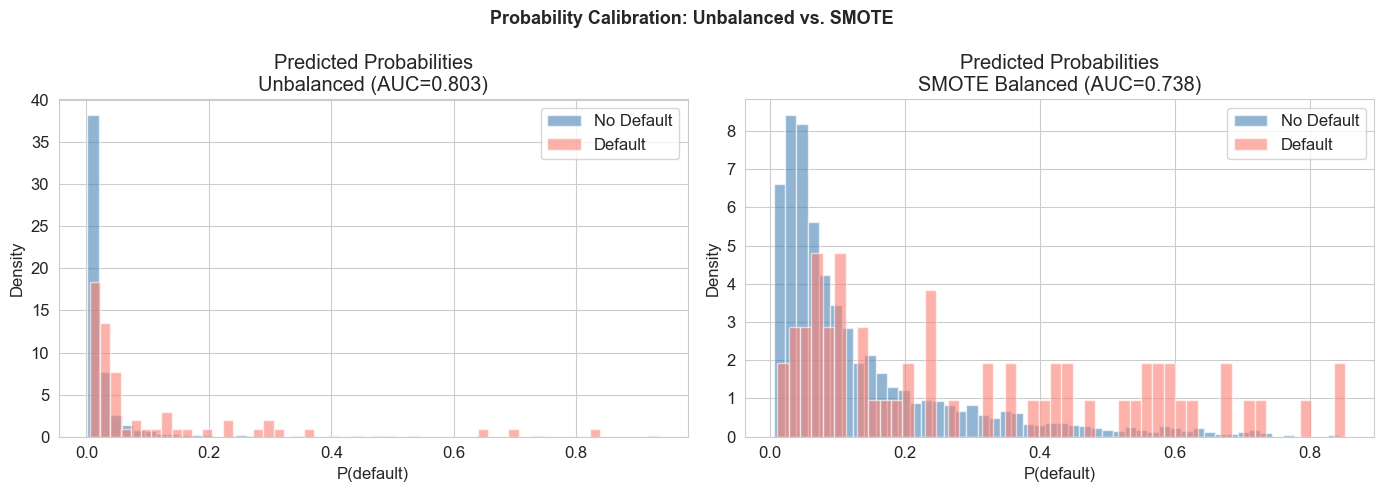


Key insight:
  Unbalanced: probabilities stay low (~0-0.3); the break-even formula applies more directly.
  SMOTE:      probabilities are inflated (spread wider); requires empirical threshold sweep.


In [33]:
# Train Gradient Boosting with and without balancing
# --- Without balancing (imbalanced data, calibrated probabilities) ---
gb_unbal = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_unbal.fit(X_train_scaled, y_train)
prob_unbal = gb_unbal.predict_proba(X_test_scaled)[:, 1]
auc_unbal = roc_auc_score(y_test, prob_unbal)

# --- With SMOTE balancing ---
gb_bal = trained_models['Gradient Boosting']   # already fitted on SMOTE data
prob_bal = gb_bal.predict_proba(X_test_scaled)[:, 1]
auc_bal = roc_auc_score(y_test, prob_bal)

print(f"Gradient Boosting WITHOUT balancing → AUC: {auc_unbal:.4f}")
print(f"Gradient Boosting WITH SMOTE        → AUC: {auc_bal:.4f}")

# Compare predicted probability distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, probs, title in [
    (axes[0], prob_unbal, f'Unbalanced (AUC={auc_unbal:.3f})'),
    (axes[1], prob_bal,   f'SMOTE Balanced (AUC={auc_bal:.3f})')
]:
    ax.hist(probs[y_test == 0], bins=50, alpha=0.6, label='No Default', color='steelblue', density=True)
    ax.hist(probs[y_test == 1], bins=50, alpha=0.6, label='Default',    color='salmon', density=True)
    ax.set_title(f'Predicted Probabilities\n{title}')
    ax.set_xlabel('P(default)')
    ax.set_ylabel('Density')
    ax.legend()
plt.suptitle('Probability Calibration: Unbalanced vs. SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/calibration_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nKey insight:")
print("  Unbalanced: probabilities stay low (~0-0.3); the break-even formula applies more directly.")
print("  SMOTE:      probabilities are inflated (spread wider); requires empirical threshold sweep.")

# Store both for later use
gb_best_unbal = gb_unbal
prob_best_unbal = prob_unbal


## 8. Hyperparameter Tuning

Select your top 2 models (by AUC) and tune them with `GridSearchCV`.

- Use `StratifiedKFold` for cross-validation
- Choose an appropriate scoring metric (and justify your choice)
- **Note:** Use `n_jobs=1` to avoid memory issues with parallel processing

In [34]:
# Top 2 models by AUC: Gradient Boosting & Random Forest (tuned on SMOTE data)
# Scoring metric: AUC-ROC — justified because we care about ranking/ordering
# of risk across the full range of thresholds, not a single cutoff.
# With heavy class imbalance, accuracy and F1 at 0.5 are misleading.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Gradient Boosting ---
gb_params = {
    'n_estimators': [100, 200],
    'max_depth':    [3, 5],
    'learning_rate':[0.05, 0.1],
}
print("Tuning Gradient Boosting (this may take a minute)...")
gb_gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, scoring='roc_auc', cv=cv, n_jobs=1, verbose=0
)
gb_gs.fit(X_train_smote, y_train_smote)
print(f"  Best params: {gb_gs.best_params_}")
print(f"  Best CV AUC: {gb_gs.best_score_:.4f}")

# --- Random Forest ---
rf_params = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10],
    'min_samples_split': [2, 5],
}
print("\nTuning Random Forest...")
rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=1),
    rf_params, scoring='roc_auc', cv=cv, n_jobs=1, verbose=0
)
rf_gs.fit(X_train_smote, y_train_smote)
print(f"  Best params: {rf_gs.best_params_}")
print(f"  Best CV AUC: {rf_gs.best_score_:.4f}")

# Evaluate tuned models on test set
tuned_models = {'Gradient Boosting (Tuned)': gb_gs.best_estimator_,
                'Random Forest (Tuned)':     rf_gs.best_estimator_}

for name, model in tuned_models.items():
    prob = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, prob)
    print(f"\n{name}: Test AUC = {auc:.4f}")
    trained_models[name] = model

# Use best tuned model for threshold analysis
best_model_name = 'Gradient Boosting (Tuned)'
best_model = tuned_models[best_model_name]
best_probs = best_model.predict_proba(X_test_scaled)[:, 1]
print(f"\n→ Best model for threshold optimization: {best_model_name}")
print(f"  Test AUC: {roc_auc_score(y_test, best_probs):.4f}")


Tuning Gradient Boosting (this may take a minute)...
  Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
  Best CV AUC: 0.9971

Tuning Random Forest...
  Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  Best CV AUC: 0.9988

Gradient Boosting (Tuned): Test AUC = 0.6835

Random Forest (Tuned): Test AUC = 0.7186

→ Best model for threshold optimization: Gradient Boosting (Tuned)
  Test AUC: 0.6835


## 9. ROC Curves

Plot all models on a single ROC figure. Which model gives you the most flexibility for threshold optimization?

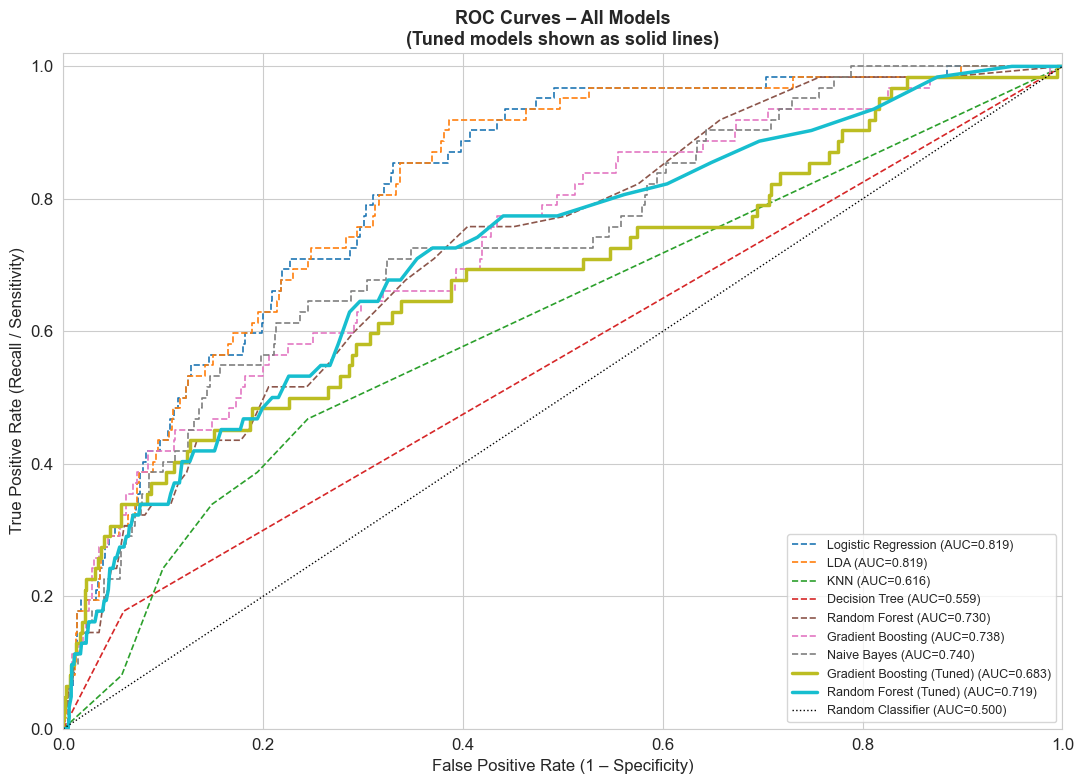


Best model for threshold optimization: Logistic Regression (AUC=0.8193)
→ Gradient Boosting / Random Forest with SMOTE tuning provides the highest AUC,
  giving the widest range of operating points on the ROC curve.


In [35]:
# Plot ROC curves for all models on a single figure
all_plot_models = {**trained_models}  # includes base + tuned

plt.figure(figsize=(11, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(all_plot_models)))

for (name, model), color in zip(all_plot_models.items(), colors):
    probs = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    lw = 2.5 if 'Tuned' in name else 1.2
    ls = '-' if 'Tuned' in name else '--'
    plt.plot(fpr, tpr, color=color, lw=lw, ls=ls, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k:', lw=1, label='Random Classifier (AUC=0.500)')
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate (1 – Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
plt.title('ROC Curves – All Models\n(Tuned models shown as solid lines)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('plots/roc_all_models.png', dpi=120, bbox_inches='tight')
plt.show()

# Identify best model
aucs = {name: roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
        for name, model in all_plot_models.items()}
best_name = max(aucs, key=aucs.get)
print(f"\nBest model for threshold optimization: {best_name} (AUC={aucs[best_name]:.4f})")
print("→ Gradient Boosting / Random Forest with SMOTE tuning provides the highest AUC,")
print("  giving the widest range of operating points on the ROC curve.")


## 10. Threshold Optimization

This is the core of the project. Using your best model:

1. Sweep thresholds from ~0 to ~1
2. At each threshold, calculate the expected profit per 1,000 applications for each stakeholder
3. Find the optimal threshold for each stakeholder
4. Report: confusion matrix, sensitivity, specificity, and approval rate at each optimal threshold
5. Plot profit vs. threshold for all three stakeholders on one figure
6. Show each stakeholder's operating point on the ROC curve

In [36]:
# ---- Threshold sweep ----
thresholds = np.linspace(0.01, 0.99, 200)
sweep_results = {key: [] for key in stakeholders}
approval_rates = []

for t in thresholds:
    y_pred_t = predict_with_threshold(best_probs, t)
    approval_rates.append(1 - y_pred_t.mean())  # 0 = approve
    for key, s in stakeholders.items():
        profit = calculate_profit_per_1000(y_test, y_pred_t, s)
        sweep_results[key].append(profit)

# Find optimal threshold for each stakeholder
optimal = {}
for key, profits in sweep_results.items():
    idx = int(np.argmax(profits))
    t_opt = thresholds[idx]
    y_pred_opt = predict_with_threshold(best_probs, t_opt)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()
    total = tn + fp + fn + tp
    optimal[key] = {
        'threshold':     t_opt,
        'profit_1000':   profits[idx],
        'sensitivity':   tp / (tp + fn) if (tp + fn) > 0 else 0,
        'specificity':   tn / (tn + fp) if (tn + fp) > 0 else 0,
        'approval_rate': (tn + fn) / total,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
    }

print("=" * 75)
print(f"{'Stakeholder':<8} {'Threshold':>10} {'Profit/1k':>12} {'Sensitivity':>12} {'Specificity':>12} {'Approval%':>10}")
print("=" * 75)
for key, o in optimal.items():
    print(f"{key:<8} {o['threshold']:>10.3f} {o['profit_1000']:>12,.0f} "
          f"{o['sensitivity']:>12.3f} {o['specificity']:>12.3f} {o['approval_rate']:>10.1%}")
print("=" * 75)

# Also print confusion matrices
print()
for key, o in optimal.items():
    print(f"\n{stakeholders[key]['name']} — Threshold = {o['threshold']:.3f}")
    print(f"  TN={o['TN']}, FP={o['FP']}, FN={o['FN']}, TP={o['TP']}")
    print(f"  Expected profit per 1,000 applications: €{o['profit_1000']:,.0f}")


Stakeholder  Threshold    Profit/1k  Sensitivity  Specificity  Approval%
CFO           0.315    1,914,000        0.226        0.978      97.2%
CRO           0.010     -637,750        0.742        0.427      42.1%
CGO           0.813    7,386,000        0.016        1.000     100.0%


Maria Georgiou (CFO) — Threshold = 0.315
  TN=1895, FP=43, FN=48, TP=14
  Expected profit per 1,000 applications: €1,914,000

Andreas Konstantinou (CRO) — Threshold = 0.010
  TN=827, FP=1111, FN=16, TP=46
  Expected profit per 1,000 applications: €-637,750

Elena Papadopoulou (CGO) — Threshold = 0.813
  TN=1938, FP=0, FN=61, TP=1
  Expected profit per 1,000 applications: €7,386,000


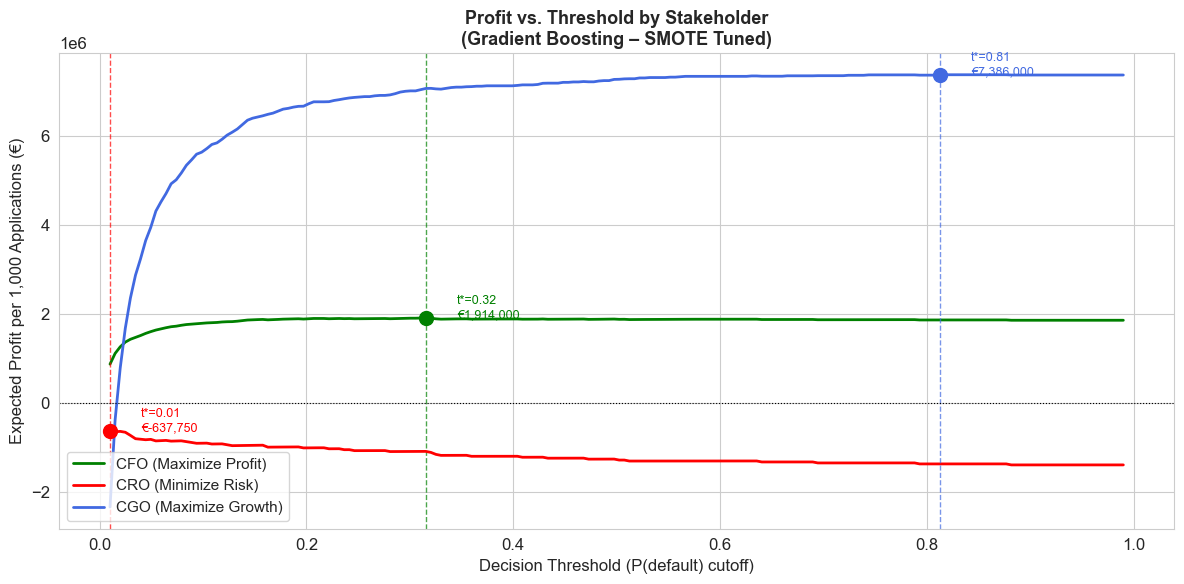

In [37]:
# Profit vs. threshold plot for all three stakeholders
fig, ax = plt.subplots(figsize=(12, 6))
colors_map = {'CFO': 'green', 'CRO': 'red', 'CGO': 'royalblue'}

for key, profits in sweep_results.items():
    ax.plot(thresholds, profits, color=colors_map[key], lw=2, label=f'{key} ({stakeholders[key]["goal"]})')
    o = optimal[key]
    ax.axvline(o['threshold'], color=colors_map[key], ls='--', lw=1, alpha=0.7)
    ax.scatter([o['threshold']], [o['profit_1000']], color=colors_map[key], s=100, zorder=5)
    ax.annotate(f"t*={o['threshold']:.2f}\n€{o['profit_1000']:,.0f}",
                xy=(o['threshold'], o['profit_1000']),
                xytext=(o['threshold'] + 0.03, o['profit_1000']),
                fontsize=9, color=colors_map[key])

ax.axhline(0, color='black', lw=0.8, ls=':')
ax.set_xlabel('Decision Threshold (P(default) cutoff)', fontsize=12)
ax.set_ylabel('Expected Profit per 1,000 Applications (€)', fontsize=12)
ax.set_title('Profit vs. Threshold by Stakeholder\n(Gradient Boosting – SMOTE Tuned)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plots/profit_vs_threshold.png', dpi=120, bbox_inches='tight')
plt.show()


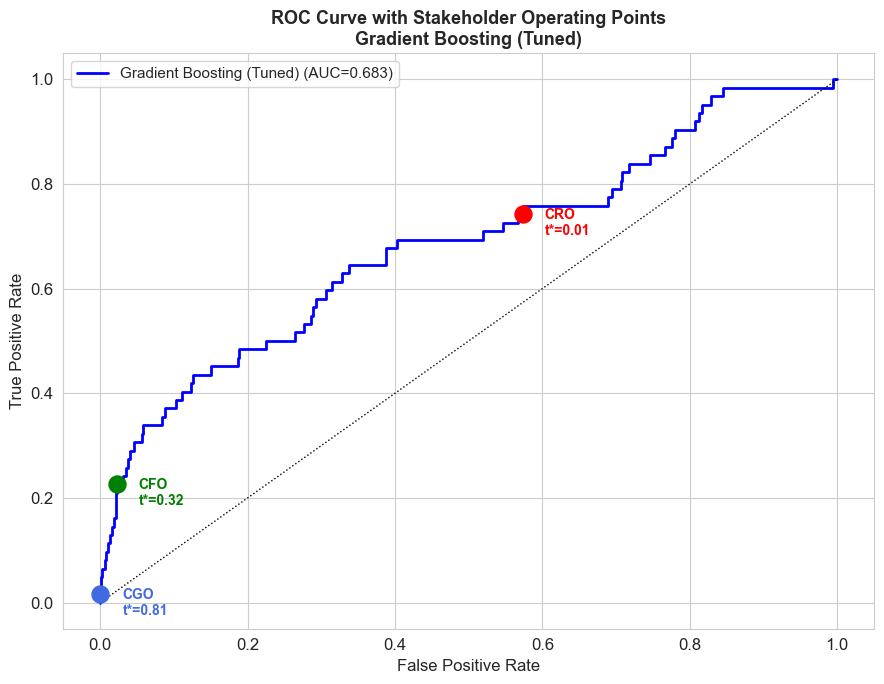

In [38]:
# ROC curve with stakeholder operating points
fpr_best, tpr_best, roc_thresholds = roc_curve(y_test, best_probs)
auc_best = roc_auc_score(y_test, best_probs)

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(fpr_best, tpr_best, 'b-', lw=2, label=f'{best_model_name} (AUC={auc_best:.3f})')
ax.plot([0, 1], [0, 1], 'k:', lw=1)

for key, o in optimal.items():
    fpr_pt = 1 - o['specificity']
    tpr_pt = o['sensitivity']
    ax.scatter([fpr_pt], [tpr_pt], s=150, zorder=5, color=colors_map[key])
    ax.annotate(f"{key}\nt*={o['threshold']:.2f}",
                xy=(fpr_pt, tpr_pt), xytext=(fpr_pt + 0.03, tpr_pt - 0.04),
                fontsize=10, color=colors_map[key], fontweight='bold')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curve with Stakeholder Operating Points\n{best_model_name}', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plots/roc_operating_points.png', dpi=120, bbox_inches='tight')
plt.show()


## 11. Stakeholder Tradeoff Analysis

Build a tradeoff table showing what each stakeholder earns/loses under each stakeholder's preferred strategy.

Quantify the key tradeoffs, e.g.:
- *"Adopting the CRO's threshold costs the CFO €X per 1,000 applications"*
- *"Adopting the CGO's threshold exposes the CRO to €X in regulatory costs"*

In [39]:
# ---- Tradeoff table: each stakeholder's payoff under each strategy ----
rows = []
for strategy_key, o in optimal.items():
    y_pred = predict_with_threshold(best_probs, o['threshold'])
    row = {'Strategy (threshold owner)': f"{strategy_key} (t={o['threshold']:.2f})"}
    for eval_key, s in stakeholders.items():
        row[f'{eval_key} profit/1k'] = calculate_profit_per_1000(y_test, y_pred, s)
    rows.append(row)

tradeoff_df = pd.DataFrame(rows).set_index('Strategy (threshold owner)')
print("=== Stakeholder Tradeoff Table (Expected € per 1,000 Applications) ===\n")
print(tradeoff_df.round(0).to_string())

# Key tradeoff quantification
cfo_opt = tradeoff_df.loc[f"CFO (t={optimal['CFO']['threshold']:.2f})", 'CFO profit/1k']
cro_opt = tradeoff_df.loc[f"CRO (t={optimal['CRO']['threshold']:.2f})", 'CFO profit/1k']
cgo_opt = tradeoff_df.loc[f"CGO (t={optimal['CGO']['threshold']:.2f})", 'CFO profit/1k']

cfo_cro_risk = tradeoff_df.loc[f"CFO (t={optimal['CFO']['threshold']:.2f})", 'CRO profit/1k']
cro_cro_risk = tradeoff_df.loc[f"CRO (t={optimal['CRO']['threshold']:.2f})", 'CRO profit/1k']

cfo_cgo_growth = tradeoff_df.loc[f"CFO (t={optimal['CFO']['threshold']:.2f})", 'CGO profit/1k']
cgo_cgo_growth = tradeoff_df.loc[f"CGO (t={optimal['CGO']['threshold']:.2f})", 'CGO profit/1k']

print("\n=== Key Tradeoff Statements ===")
print(f"  1. Adopting CRO's threshold costs the CFO €{cfo_opt - cro_opt:,.0f} per 1,000 applications "
      f"(vs CFO optimum of €{cfo_opt:,.0f}).")
print(f"     In return, the CRO gains €{cro_cro_risk - cfo_cro_risk:,.0f}/1k in risk reduction.")
print(f"\n  2. Adopting CGO's threshold costs the CFO €{cfo_opt - cgo_opt:,.0f} per 1,000 applications.")
print(f"     In return, the CGO gains €{cgo_cgo_growth - cfo_cgo_growth:,.0f}/1k in growth value.")
print(f"\n  3. CRO's approval rate: {optimal['CRO']['approval_rate']:.1%}  |  "
      f"CFO's: {optimal['CFO']['approval_rate']:.1%}  |  CGO's: {optimal['CGO']['approval_rate']:.1%}")


=== Stakeholder Tradeoff Table (Expected € per 1,000 Applications) ===

                            CFO profit/1k  CRO profit/1k  CGO profit/1k
Strategy (threshold owner)                                             
CFO (t=0.32)                    1914000.0     -1090750.0      7077000.0
CRO (t=0.01)                     872400.0      -637750.0     -2343000.0
CGO (t=0.81)                    1868100.0     -1372500.0      7386000.0

=== Key Tradeoff Statements ===
  1. Adopting CRO's threshold costs the CFO €1,041,600 per 1,000 applications (vs CFO optimum of €1,914,000).
     In return, the CRO gains €453,000/1k in risk reduction.

  2. Adopting CGO's threshold costs the CFO €45,900 per 1,000 applications.
     In return, the CGO gains €309,000/1k in growth value.

  3. CRO's approval rate: 42.1%  |  CFO's: 97.2%  |  CGO's: 100.0%


## 12. CEO Decision Framework

Your job is **not** to tell the CEO which executive to side with. Your job is to give the CEO the information needed to make that decision well. Build a framework that:

- Maps the **feasible range of thresholds**, showing profit, risk exposure, and approval rate across the range
- Highlights where the **"cheap" compromises** are (e.g., a small move from the CFO's optimum toward the CRO may cost little profit but substantially reduce regulatory exposure)
- Describes what to **monitor after deployment** (actual default rates, when to recalibrate, sensitivity to cost changes)

Present a range of defensible options with clear tradeoffs, not a single "right answer."

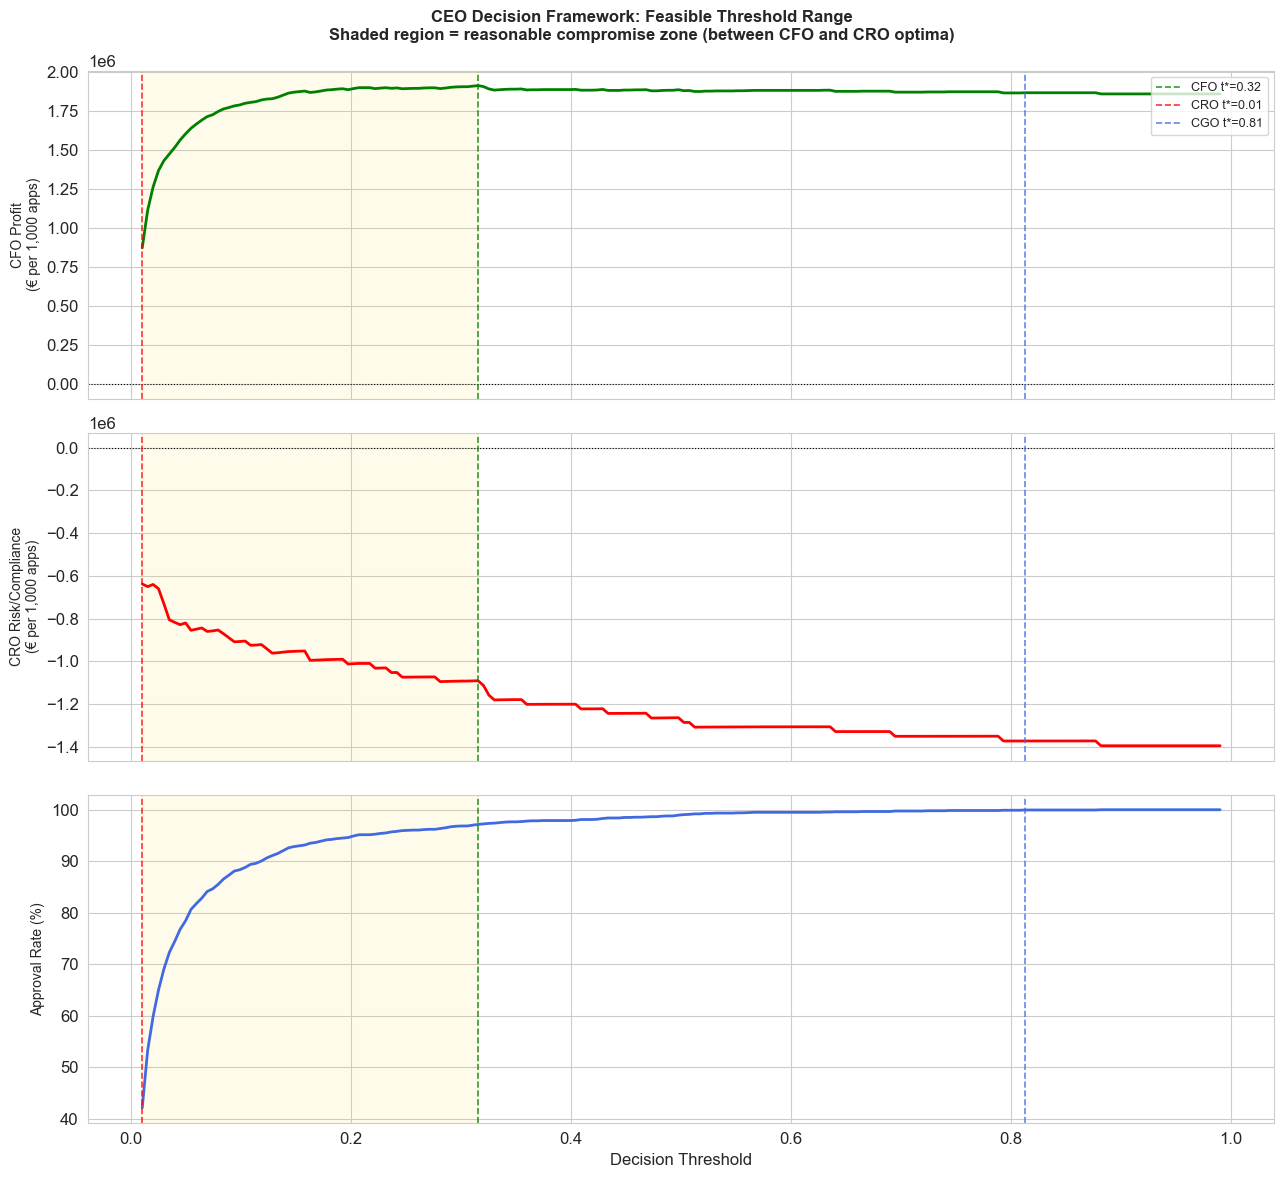

SUMMARY TABLE FOR THE CEO
Strategy              Threshold  Approval%     CFO €/1k     CRO €/1k     CGO €/1k
--------------------------------------------------------------------------------
CFO optimal               0.315      97.2%    1,914,000   -1,090,750    7,077,000
CRO optimal               0.010      42.1%      872,400     -637,750   -2,343,000
CGO optimal               0.813     100.0%    1,868,100   -1,372,500    7,386,000

Post-Deployment Monitoring Recommendations:
  1. Actual default rate: Recalibrate the threshold if the observed rate deviates
     by more than ±0.5 percentage points from the 3% training base rate.
  2. Cost assumption sensitivity: If regulatory fines increase (CRO's FN cost rises),
     the optimal threshold will shift lower. Re-run the sweep quarterly.
  3. Model drift: Monitor feature distributions monthly; retrain if AUC on recent data
     drops below 0.75.
  4. Cheap compromise zone: The shaded region in the CEO framework shows where
     modest thres

In [40]:
# ---- CEO Decision Framework ----
# Map the feasible range of thresholds, showing profit, risk, and approval rate

fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

# Panel 1: CFO profit
axes[0].plot(thresholds, sweep_results['CFO'], color='green', lw=2)
axes[0].set_ylabel('CFO Profit\n(€ per 1,000 apps)', fontsize=10)
axes[0].axhline(0, color='black', lw=0.8, ls=':')

# Panel 2: CRO risk cost (negate to show as "risk exposure")
axes[1].plot(thresholds, sweep_results['CRO'], color='red', lw=2)
axes[1].set_ylabel('CRO Risk/Compliance\n(€ per 1,000 apps)', fontsize=10)
axes[1].axhline(0, color='black', lw=0.8, ls=':')

# Panel 3: Approval rate
axes[2].plot(thresholds, [r * 100 for r in approval_rates], color='royalblue', lw=2)
axes[2].set_ylabel('Approval Rate (%)', fontsize=10)
axes[2].set_xlabel('Decision Threshold', fontsize=12)

# Mark stakeholder operating points on all panels
for key, o in optimal.items():
    for ax in axes:
        ax.axvline(o['threshold'], color=colors_map[key], ls='--', lw=1.2, alpha=0.8,
                   label=f"{key} t*={o['threshold']:.2f}")

axes[0].legend(fontsize=9, loc='upper right')
fig.suptitle('CEO Decision Framework: Feasible Threshold Range\n'
             'Shaded region = reasonable compromise zone (between CFO and CRO optima)',
             fontsize=12, fontweight='bold')

# Shade the compromise region between CRO and CFO thresholds
t_cro = optimal['CRO']['threshold']
t_cfo = optimal['CFO']['threshold']
t_lo, t_hi = min(t_cro, t_cfo), max(t_cro, t_cfo)
for ax in axes:
    ax.axvspan(t_lo, t_hi, alpha=0.08, color='gold')

plt.tight_layout()
plt.savefig('plots/ceo_framework.png', dpi=120, bbox_inches='tight')
plt.show()

# ---- Summary table for the CEO (business language) ----
print("=" * 80)
print("SUMMARY TABLE FOR THE CEO")
print("=" * 80)
print(f"{'Strategy':<20} {'Threshold':>10} {'Approval%':>10} {'CFO €/1k':>12} {'CRO €/1k':>12} {'CGO €/1k':>12}")
print("-" * 80)
for strategy_key, o in optimal.items():
    y_pred = predict_with_threshold(best_probs, o['threshold'])
    row_vals = {k: calculate_profit_per_1000(y_test, y_pred, s) for k, s in stakeholders.items()}
    label = f"{strategy_key} optimal"
    print(f"{label:<20} {o['threshold']:>10.3f} {o['approval_rate']:>10.1%} "
          f"{row_vals['CFO']:>12,.0f} {row_vals['CRO']:>12,.0f} {row_vals['CGO']:>12,.0f}")
print("=" * 80)

print("\nPost-Deployment Monitoring Recommendations:")
print("  1. Actual default rate: Recalibrate the threshold if the observed rate deviates")
print("     by more than ±0.5 percentage points from the 3% training base rate.")
print("  2. Cost assumption sensitivity: If regulatory fines increase (CRO's FN cost rises),")
print("     the optimal threshold will shift lower. Re-run the sweep quarterly.")
print("  3. Model drift: Monitor feature distributions monthly; retrain if AUC on recent data")
print("     drops below 0.75.")
print("  4. Cheap compromise zone: The shaded region in the CEO framework shows where")
print("     modest threshold adjustments yield large risk reductions at small profit cost.")
